Zaimplementuj algorytm optymalizacji roju cząstek (PSO).    
Zastosuj zwiększanie parametrów odpowiadających za ufność wiedzy cząstki po pewnym czasie działania algorytmu.   
Przy pomocy algorytmu optymalizacji rojem cząstek, naucz system ANFIS.   
Celem optymalizacji jest zminimalizowanie błędu osiąganego przez ANFIS (o wartościach parametrów reprezentowanych przez cząstkę)   
na zbiorze danych. Przetestuj działanie algorytmu PSO w zależności od zadanych parametrów.   

# Initialize Particle

In [126]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.model_selection import train_test_split
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids
from ANFIS import ANFIS
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

LOWER_BOUND = -4.5
UPPER_BOUND = 4.5
PROBLEM_DIMENSIONS = 2


class Particle():
    """Single particle in the swarm optimization algorithm"""
    def __init__(self, dim: int, bounds: tuple[float, float]):
        """
        Initializes a particle with a random state
        
        Args:
            dim (int): Dimensionality of the problem
            bounds (tuple): (min_value, max_value) for parameters
        """
        self.dim = dim
        self.bounds = bounds
        low, high = bounds

        # Initialize the particle with random guess
        self.current_position = np.random.uniform(low, high, dim) # third argument is a size
        
        # Initialize velocity as 10% of the search space
        v_limit = (high - low) * 0.1
        
        # initialize the velocity of the particle
        self.velocity = np.random.uniform(-v_limit, v_limit, dim)

        # Initialize personal best value of the particle
        self.personal_best_position = self.current_position.copy() 
        self.personal_best_value = float('inf')



In [127]:
# def fitness_function(position: np.ndarray) -> float:
#     """
#     Calculate the fitness value for a given position (f(x,y)).
    
#     Args:
#         position (np.ndarray): The particle's position, coordinates (x,y)
#     """
#     x, y = position[0], position[1]
#     term1 = (1.5 - x - x*y)**2
#     term2 = (2.25 - x + x*y**2)**2
#     term3 = (2.625 - x + x*y**3)**2
#     return term1 + term2 + term3

# Create PSO Optimizer

In [128]:
class PSOOptimizer():
    """The Particle Swarm Optimization algorithm"""
    def __init__(self,
                fitness_func, 
                problem_dim : int,
                bounds: tuple[float, float],
                n_particles: int = 30,

                # Inertia decay
                w_start: float = 0.9,
                w_end: float = 0.4,

                # Congnitive increasing
                c1_start: float = 0.5,
                c1_end: float = 2.5,

                # Social decreasing
                c2_start: float = 2.5,
                c2_end: float = 0.5):

        """
        Initializes the PSO Optimizer.

        Args:
            function (callable): The function to minimize. It must take a numpy array of positions. Anfis error.
            n_particles (int): The number oof particles in the swarm.
            w (float): The inertia weight. Controls the particle's tendency to keep moving in its current direction. A high value
                like 0.9 encourages global exploration, because its is hard to stop. Smaller like 0.4 encourages local exploration.
            c1 (float): The cognitive coefficient. The value controls the 'pull' of the particle towards its own personal best position
            c2 (float): The social coefficient. The value controls the 'pull' of the particle towards swarm's best position
        """
        self.fitness_func = fitness_func
        self.dim = problem_dim
        self.bounds = bounds
        self.n_particles = n_particles

        # Dynamic parameters
        self.w_start, self.w_end = w_start, w_end
        self.c1_start, self.c1_end = c1_start, c1_end
        self.c2_start, self.c2_end = c2_start, c2_end

        # Current parameters
        self.w = w_start
        self.c1 = c1_start
        self.c2_ = c2_start

        # Initialize global best state
        self.gbest_position = None
        self.gbest_value = float('inf')
        
        # Create particles
        self.particles = [Particle(self.dim, self.bounds) for _ in range(self.n_particles)]

        # Initialize swarm's pbest and gbest
        self._initialize_swarm()

    
    def _initialize_swarm(self):
        """Initialize the personal and global best values for the swarm"""
        # Loop over the already existing particle list
        for particle in self.particles:
            particle.personal_best_value = self.fitness_func(particle.current_position) # The particle's current fitness is its first and only
            
            # Particle's personal best position is copied of current position during initialization 
            if particle.personal_best_value < self.gbest_value:
                self.gbest_value = particle.personal_best_value
                self.gbest_position = particle.personal_best_position.copy()

    
    def _update_parameters(self, current_iter, max_iter):
        """Updates w, c1, and c2 based on iterations"""
        # Linear interpolation 
        scale_factor = current_iter / max_iter

        # Inertia weight decays
        self.w = self.w_start - (self.w_start - self.w_end) * scale_factor

        # Congnitive trust increases
        self.c1 = self.c1_start + (self.c1_end - self.c1_start) * scale_factor

        # Social trust decreases
        self.c2 = self.c2_start + (self.c2_end - self.c2_start) * scale_factor

    
    def _optimize(self, max_iterations: int) -> tuple[np.ndarray, float]:
        """
        Internal Function of optimizing the Particle Swarm Algorithm
        
        Returns:
            A tuple containing (best_position, best_value)
        """
        history = []
        low, high = self.bounds
        
        for it in range(max_iterations):
            
            # Update dynamic , w, c1, c2
            self._update_parameters(it, max_iterations)

            for particle in self.particles: # For every particle
                
                # Update velocity
                # r1,r2 random numbers that add chaos so particles don't move in straight lines
                r1 = np.random.rand(self.dim) # r1 = [dx, dy] becose below there will be broadcasting 
                r2 = np.random.rand(self.dim)

                # Cognivite pull me toward my best spot
                cognitive_term = (self.c1 * r1 * (particle.personal_best_position - particle.current_position))
                
                # Pull me toward the leader's best spot
                social_term = self.c2 * r2 * (self.gbest_position - particle.current_position)

                # Vector that decides direction 
                new_velocity =  (self.w * particle.velocity) + cognitive_term + social_term
                
                # Update new position
                new_position = particle.current_position + new_velocity

                # Handling boundaries, if particle will hit the wall they, the particle  stop at the wall
                clipped_position = np.clip(new_position, low, high)

                # Asign new posiion to paticle
                particle.current_position = clipped_position

                # Calculate fitness
                current_value = self.fitness_func(particle.current_position)

                # Compare pbest value and pb_position
                if current_value < particle.personal_best_value:
                    particle.personal_best_value = current_value
                    particle.personal_best_position = particle.current_position.copy()

                # Compare pbest value with swarm's best value
                if particle.personal_best_value < self.gbest_value:
                    self.gbest_value = particle.personal_best_value
                    self.gbest_position = particle.personal_best_position.copy()

            history.append(self.gbest_value)

            if it % 10 == 0:
                print(f"Iter {it}/{max_iterations}, beest value: {self.gbest_value}, c1: {self.c1:.2f}, c2: {self.c2:.2f}")

        return self.gbest_position, self.gbest_value, history
    
    # def optimize(self, max_iterations: int) -> tuple[np.ndarray, float, list]:
    #     """Runs the PSO algorithm and records the covergance history"""
    #     history = [] # A list to store global best value at each iteration
    #     for _ in range(max_iterations):
    #         self._optimize_single_run()
    #         history.append(self.gbest_value)
    #     return self.gbest_position, self.gbest_value, history
    

    # def optimize_generator(self, max_iterations: int):
    #     """A generator that yields the state of the swarm at each iteration"""
    #     for _ in range(max_iterations):
    #         self._optimize_single_run()
    #         yield self.particles, self.gbest_position

In [129]:
class PSO_ANFIS_Bridge:
    """Class for connection between PSO and ANFIS"""
    def __init__(self, anfis):
        self.anfis = anfis

        # We optimize premises (shapes) with PSO so we want flatten, example [center1, width1, center2, width2]
        flat_premises = np.array([p for sublist in anfis.premises for p in sublist]).flatten()
        self.idx_premises = len(flat_premises)

        # The particle dimension is equal the number of premises, number of inputs * number of membership functions * number of parameters for each membership functions
        # In our case 2 inputs: X,Y * 2  membership func varX, varY * 2 parameters center, width 
        self.dim = self.idx_premises

    def _get_firing_matrix(self, new_premises):
        """Helper to calculate Rule Activation for LSE, so it will answer how each rule is active"""
        # Update anfis with the new parameters
        self.anfis.set_premises_parameters(new_premises)

        data = self.anfis.training_data

        # Fuzzyfying input data
        memberships = [self.anfis.input_list[x].fuzzify(data[x]) for x in range(self.anfis.input_number)]

        
        arguments = []
        # We are going through permutations of premises, like varX is low and varY is high, etc,,
        for premises in self.anfis.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:, premises[i]])
            arguments.append(item)

        # Transpose to inputs samples rules for min
        arguments = np.transpose(arguments, (1,2,0))

        # Apply min operator zadeh, so from two values X, Y it will take a lower
        R = np.min(arguments, axis=0)

        # Normalize because AFNIS expects it
        Rsum = np.sum(R, axis=1, keepdims=True)
        Rnorm = R / (Rsum + 1e-8)

        return Rnorm
    

    def _constrain_XOR_particle(self, position):
        """Enforce logical limits on the particle's data"""
        corrected = position.copy()
        for i in range(0, self.idx_premises, 2):
            # Center keep roughly witihn 0-1
            corrected[i] = np.clip(corrected[i], -0.2, 1.2)

            # Width, keep small and postiive for sharp xor steps
            corrected[i+1] = np.clip(np.abs(corrected[i+1]), 0.01, 0.8)
        return corrected
    
    
    def _constrain_mutli_table_particle(self, position):
        """Enforce logical limits on the particle's data"""
        corrected = position.copy()
        for i in range(0, self.idx_premises, 4):
            # Center keep roughly witihn 0-1
            segment = np.clip(corrected[i:i+4], -1, 6.0)

            # Width, keep small and postiive for sharp xor steps
            corrected[i:i+4] = np.sort(segment)

            if corrected[i+3] - corrected[i] < 0.1:
                corrected[i+3] += 0.1
                
        return corrected
    

    def get_error(self, position: np.ndarray) -> float:
        """
        The cost function for PSO, MSE is used.
        """
        # Constrain, apply some limitations 
        position = self._constrain_XOR_particle(position)
        new_premises = position.reshape(np.shape(self.anfis.premises))

        try:
            # Hybrid LSE Step
            A = self._get_firing_matrix(new_premises)

            # Solve for A * x = y to find best weights x, LSE - Least Squares Estimation 
            optimal_weights, _, rank, _ = np.linalg.lstsq(A, self.anfis.expected_labels)

            # Calculate predition and error
            predictions = np.dot(A, optimal_weights)

            # Lets apply MSE
            mse = np.mean((predictions - self.anfis.expected_labels)**2)

            # Penalty for dead rules, if rules don't fire rank is low
            if rank < A.shape[1]:
                return 1000 + mse # big penalty
            
            return mse
        
        except Exception:
            return 1000 # Fail safe
        
    
    def update_model(self, best_position, isXOR: bool=True):
        """Update the anfis object with the best result from PSO"""
        if isXOR:
            best_position = self._constrain_XOR_particle(best_position)
        else:
            best_position = self._constrain_mutli_table_particle(best_position)

        new_premises = best_position.reshape(np.shape(self.anfis.premises))
        self.anfis.set_premises_parameters(new_premises)

        # Recalculate best weights one last time with LSE
        A = self._get_firing_matrix(new_premises)
        optimal_weights, _, rank, _ = np.linalg.lstsq(A, self.anfis.expected_labels, rcond=None)

        # Update TSK-0 weigts
        n_rules = len(optimal_weights)
        n_inputs = self.anfis.input_number
        new_tsk = np.zeros((n_rules, n_inputs + 1))

        # Why we take only last column? Because our output Z for a rule is calculates as p*q + q*y + r 
        # And in the XOR we expects terraces so therefore we require to p and q = 0  and we are looking for r
        new_tsk[:, -1] = optimal_weights
        self.anfis.tsk = new_tsk
        

# Data preparation

Starting PSO...
Iter 0/100, beest value: 0.046153563110298355, c1: 0.50, c2: 2.50
Iter 10/100, beest value: 2.3421079093812598e-35, c1: 0.70, c2: 2.30
Iter 20/100, beest value: 2.3421079093812598e-35, c1: 0.90, c2: 2.10
Iter 30/100, beest value: 2.3421079093812598e-35, c1: 1.10, c2: 1.90
Iter 40/100, beest value: 2.3421079093812598e-35, c1: 1.30, c2: 1.70
Iter 50/100, beest value: 2.3421079093812598e-35, c1: 1.50, c2: 1.50
Iter 60/100, beest value: 2.3421079093812598e-35, c1: 1.70, c2: 1.30
Iter 70/100, beest value: 2.3421079093812598e-35, c1: 1.90, c2: 1.10
Iter 80/100, beest value: 2.3421079093812598e-35, c1: 2.10, c2: 0.90
Iter 90/100, beest value: 2.3421079093812598e-35, c1: 2.30, c2: 0.70
Best MSE: 2.3421079093812598e-35


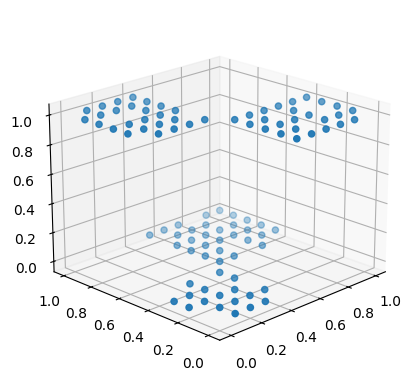

[[15  0]
 [ 0 10]]


In [130]:
x = np.arange(0, 1.1, 0.1)
x, y = np.meshgrid(x, x)
dataX = x.flatten()
dataY = y.flatten()
dataXY = np.column_stack((dataX, dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5).astype(float)

X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=42)

def zadeh_t(args, op=None):
    return np.min(args, axis=0)

varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "X", ["L", "H"])
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "Y", ["L", "H"])

# Initialize ANFIS
fis = ANFIS([varX, varY], X_train.T, y_train, operator_function=zadeh_t)

bridge = PSO_ANFIS_Bridge(fis)
problem_dim = bridge.dim

def run_experiment(name, c1_val, c2_val):
    print(f"Parameters: Trust self c1={c1_val}, trust swarm c2={c2_val}")

    
pso = PSOOptimizer(
    fitness_func=bridge.get_error,
    problem_dim=problem_dim,
    bounds=(0, 1),
    n_particles=30,
    c1_start=0.5,
    c1_end=2.5,
    c2_start=2.5,
    c2_end=0.5,
    w_start=0.9,
    w_end=0.4
)

print("Starting PSO...")
best_pos, best_err, history = pso._optimize(max_iterations=100)
print(f"Best MSE: {best_err}")

bridge.update_model(best_pos)

fis.show_results()

fis.training_data = X_test.T
fis.expected_labels = y_test
y_pred = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
y_pred_rounded = np.round(y_pred.flatten())

print(confusion_matrix(y_test, y_pred_rounded))

# Run experiment

Starting comparison on 4 parameters...
Running: Explore->Converge...
Iter 0/80, beest value: 0.023963996649862363, c1: 2.50, c2: 0.50
Iter 10/80, beest value: 0.0074003798630887276, c1: 2.25, c2: 0.75
Iter 20/80, beest value: 0.0, c1: 2.00, c2: 1.00
Iter 30/80, beest value: 0.0, c1: 1.75, c2: 1.25
Iter 40/80, beest value: 0.0, c1: 1.50, c2: 1.50
Iter 50/80, beest value: 0.0, c1: 1.25, c2: 1.75
Iter 60/80, beest value: 0.0, c1: 1.00, c2: 2.00
Iter 70/80, beest value: 0.0, c1: 0.75, c2: 2.25
Final Error: 0.000000
Running: Converge->Explore...
Iter 0/80, beest value: 0.009383565444536283, c1: 0.50, c2: 2.50
Iter 10/80, beest value: 0.0, c1: 0.75, c2: 2.25
Iter 20/80, beest value: 0.0, c1: 1.00, c2: 2.00
Iter 30/80, beest value: 0.0, c1: 1.25, c2: 1.75
Iter 40/80, beest value: 0.0, c1: 1.50, c2: 1.50
Iter 50/80, beest value: 0.0, c1: 1.75, c2: 1.25
Iter 60/80, beest value: 0.0, c1: 2.00, c2: 1.00
Iter 70/80, beest value: 0.0, c1: 2.25, c2: 0.75
Final Error: 0.000000
Running: Constant Balan

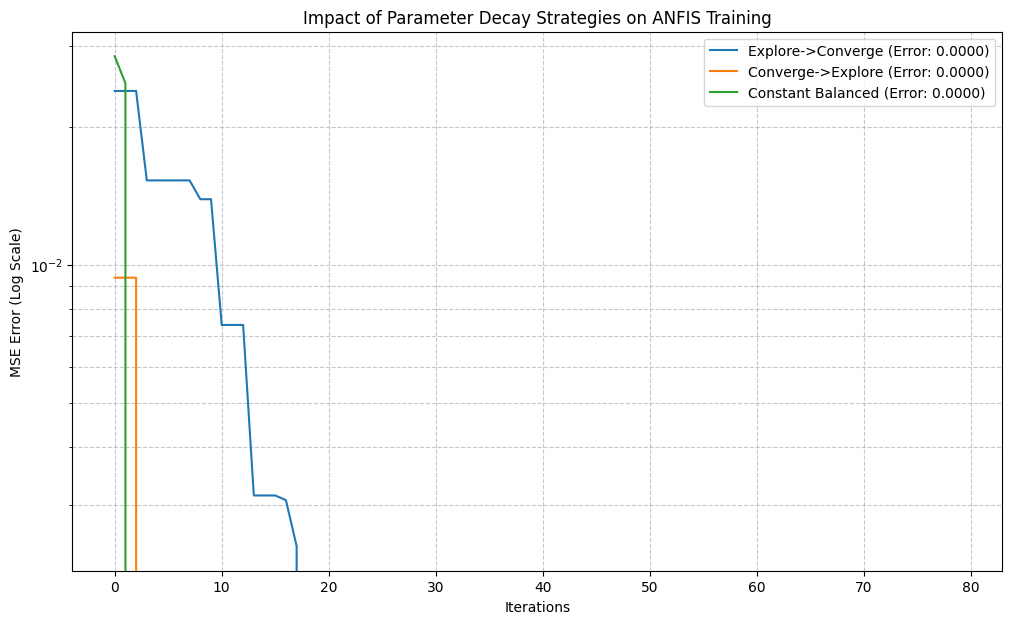


 Won: Explore->Converge


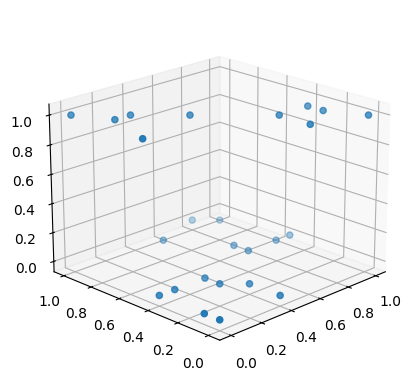

[[15  0]
 [ 0 10]]


In [131]:
ITERATIONS = 80
N_PARTICLES = 30

# Define the 3 strategies
strategies = {
    "Explore->Converge": {
        "w_start": 0.9, "w_end": 0.4,
        "c1_start": 2.5, "c1_end": 0.5,  # Self trust goes DOWN
        "c2_start": 0.5, "c2_end": 2.5   # Swarm trust goes UP
    },
    "Converge->Explore": {
        "w_start": 0.9, "w_end": 0.4,
        "c1_start": 0.5, "c1_end": 2.5,  # Self trust goes UP
        "c2_start": 2.5, "c2_end": 0.5   # Swarm trust goes DOWN
    },
    "Constant Balanced": {
        "w_start": 0.7, "w_end": 0.7,    # Fixed Inertia
        "c1_start": 1.49, "c1_end": 1.49, # Fixed Self
        "c2_start": 1.49, "c2_end": 1.49  # Fixed Swarm
    }
}


results = {}

print(f"Starting comparison on {bridge.dim} parameters...")

for name, params in strategies.items():
    print(f"Running: {name}...")
    
    # Initialize Optimizer with specific params
    pso = PSOOptimizer(
        fitness_func=bridge.get_error,
        problem_dim=bridge.dim,
        bounds=(0, 1),
        n_particles=N_PARTICLES,
        **params # Unpack the strategy parameters
    )
    
    # Run
    best_pos, best_err, history = pso._optimize(max_iterations=ITERATIONS)
    
    # Store results
    results[name] = {
        "history": history,
        "final_error": best_err,
        "best_pos": best_pos
    }
    print(f"Final Error: {best_err:.6f}")


plt.figure(figsize=(12, 7))

for name, data in results.items():
    plt.plot(data["history"], label=f"{name} (Error: {data['final_error']:.4f})")

plt.title("Impact of Parameter Decay Strategies on ANFIS Training")
plt.xlabel("Iterations")
plt.ylabel("MSE Error (Log Scale)")
plt.yscale('log') # Crucial to see convergence details
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 
best_strategy_name = min(results, key=lambda k: results[k]["final_error"])
print(f"\n Won: {best_strategy_name}")

# Apply winner to model
bridge.update_model(results[best_strategy_name]["best_pos"])
fis.show_results()

fis.training_data = X_test.T
fis.expected_labels = y_test
y_pred = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
y_pred_rounded = np.round(y_pred.flatten())

print(confusion_matrix(y_test, y_pred_rounded))